In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gmean

In [2]:
RESULTS_DIR = Path.cwd().parent / "results"
FIGURES_DIR = Path.cwd().parent / "figures"

TARGETS = ["cusparse1", "cusparse2", "opsparse", "proposal"]
LEGEND = ["cuSPARSE 1", "cuSPARSE 2", "OpSPARSE", "Proposal"]

TIME_COLS = ["cusparse1-time", "cusparse2-time", "opsparse-time", "proposal-time"]
GFLOPS_COLS = [
    "cusparse1-gflops",
    "cusparse2-gflops",
    "opsparse-gflops",
    "proposal-gflops",
]

Y_LIMIT = 100

In [3]:
def load_results(CLUSTER: str, variant: str) -> pd.DataFrame:
    directory = RESULTS_DIR / CLUSTER
    dfs = []
    for target in TARGETS:
        df = pd.read_csv(directory / f"{target}-{variant}.csv")
        df = df.rename(columns={"time_ns": "time"})
        df["gflops"] = df["flops"] / 1e9
        df = df.groupby("matrix", sort=False).mean(numeric_only=True)
        df = df.add_prefix(f"{target}-")
        dfs.append(df)
    return pd.concat(dfs, axis=1)


def save_gflops_plot(df: pd.DataFrame, filename: Path):
    fig, ax = plt.subplots(dpi=400)
    df.plot(y=GFLOPS_COLS, kind="bar", figsize=(10, 6), ax=ax)
    ax.set_ylim(0, Y_LIMIT)
    ax.set_xlabel("Matrix", fontweight="bold")
    ax.set_ylabel("GFLOPS", fontweight="bold")
    ax.legend(LEGEND, loc="upper left")
    plt.tight_layout()
    plt.savefig(filename)


def get_best_performing(df: pd.DataFrame, algo: str) -> int:
    main = f"{algo}-gflops"
    others = [c for c in GFLOPS_COLS if c != main]

    n_best_performing = (df[main] > df[others].max(axis=1)).sum()
    return n_best_performing

## ClusterFIT

## Float best performing
cusparse1: 0
cusparse2: 0
opsparse: 6
proposal: 6
## Double best performing
cusparse1: 0
cusparse2: 0
opsparse: 5
proposal: 7

## Float speedups
Proposal speedup over cusparse1: 3.34
Proposal speedup over cusparse2: 2.37
Proposal speedup over opsparse: 1.48

## Double speedups
Proposal speedup over cusparse1: 4.22
Proposal speedup over cusparse2: 2.56
Proposal speedup over opsparse: 1.53

## Double is better than float
cusparse1-gflops    1
cusparse2-gflops    0
opsparse-gflops     3
proposal-gflops     6
dtype: int64


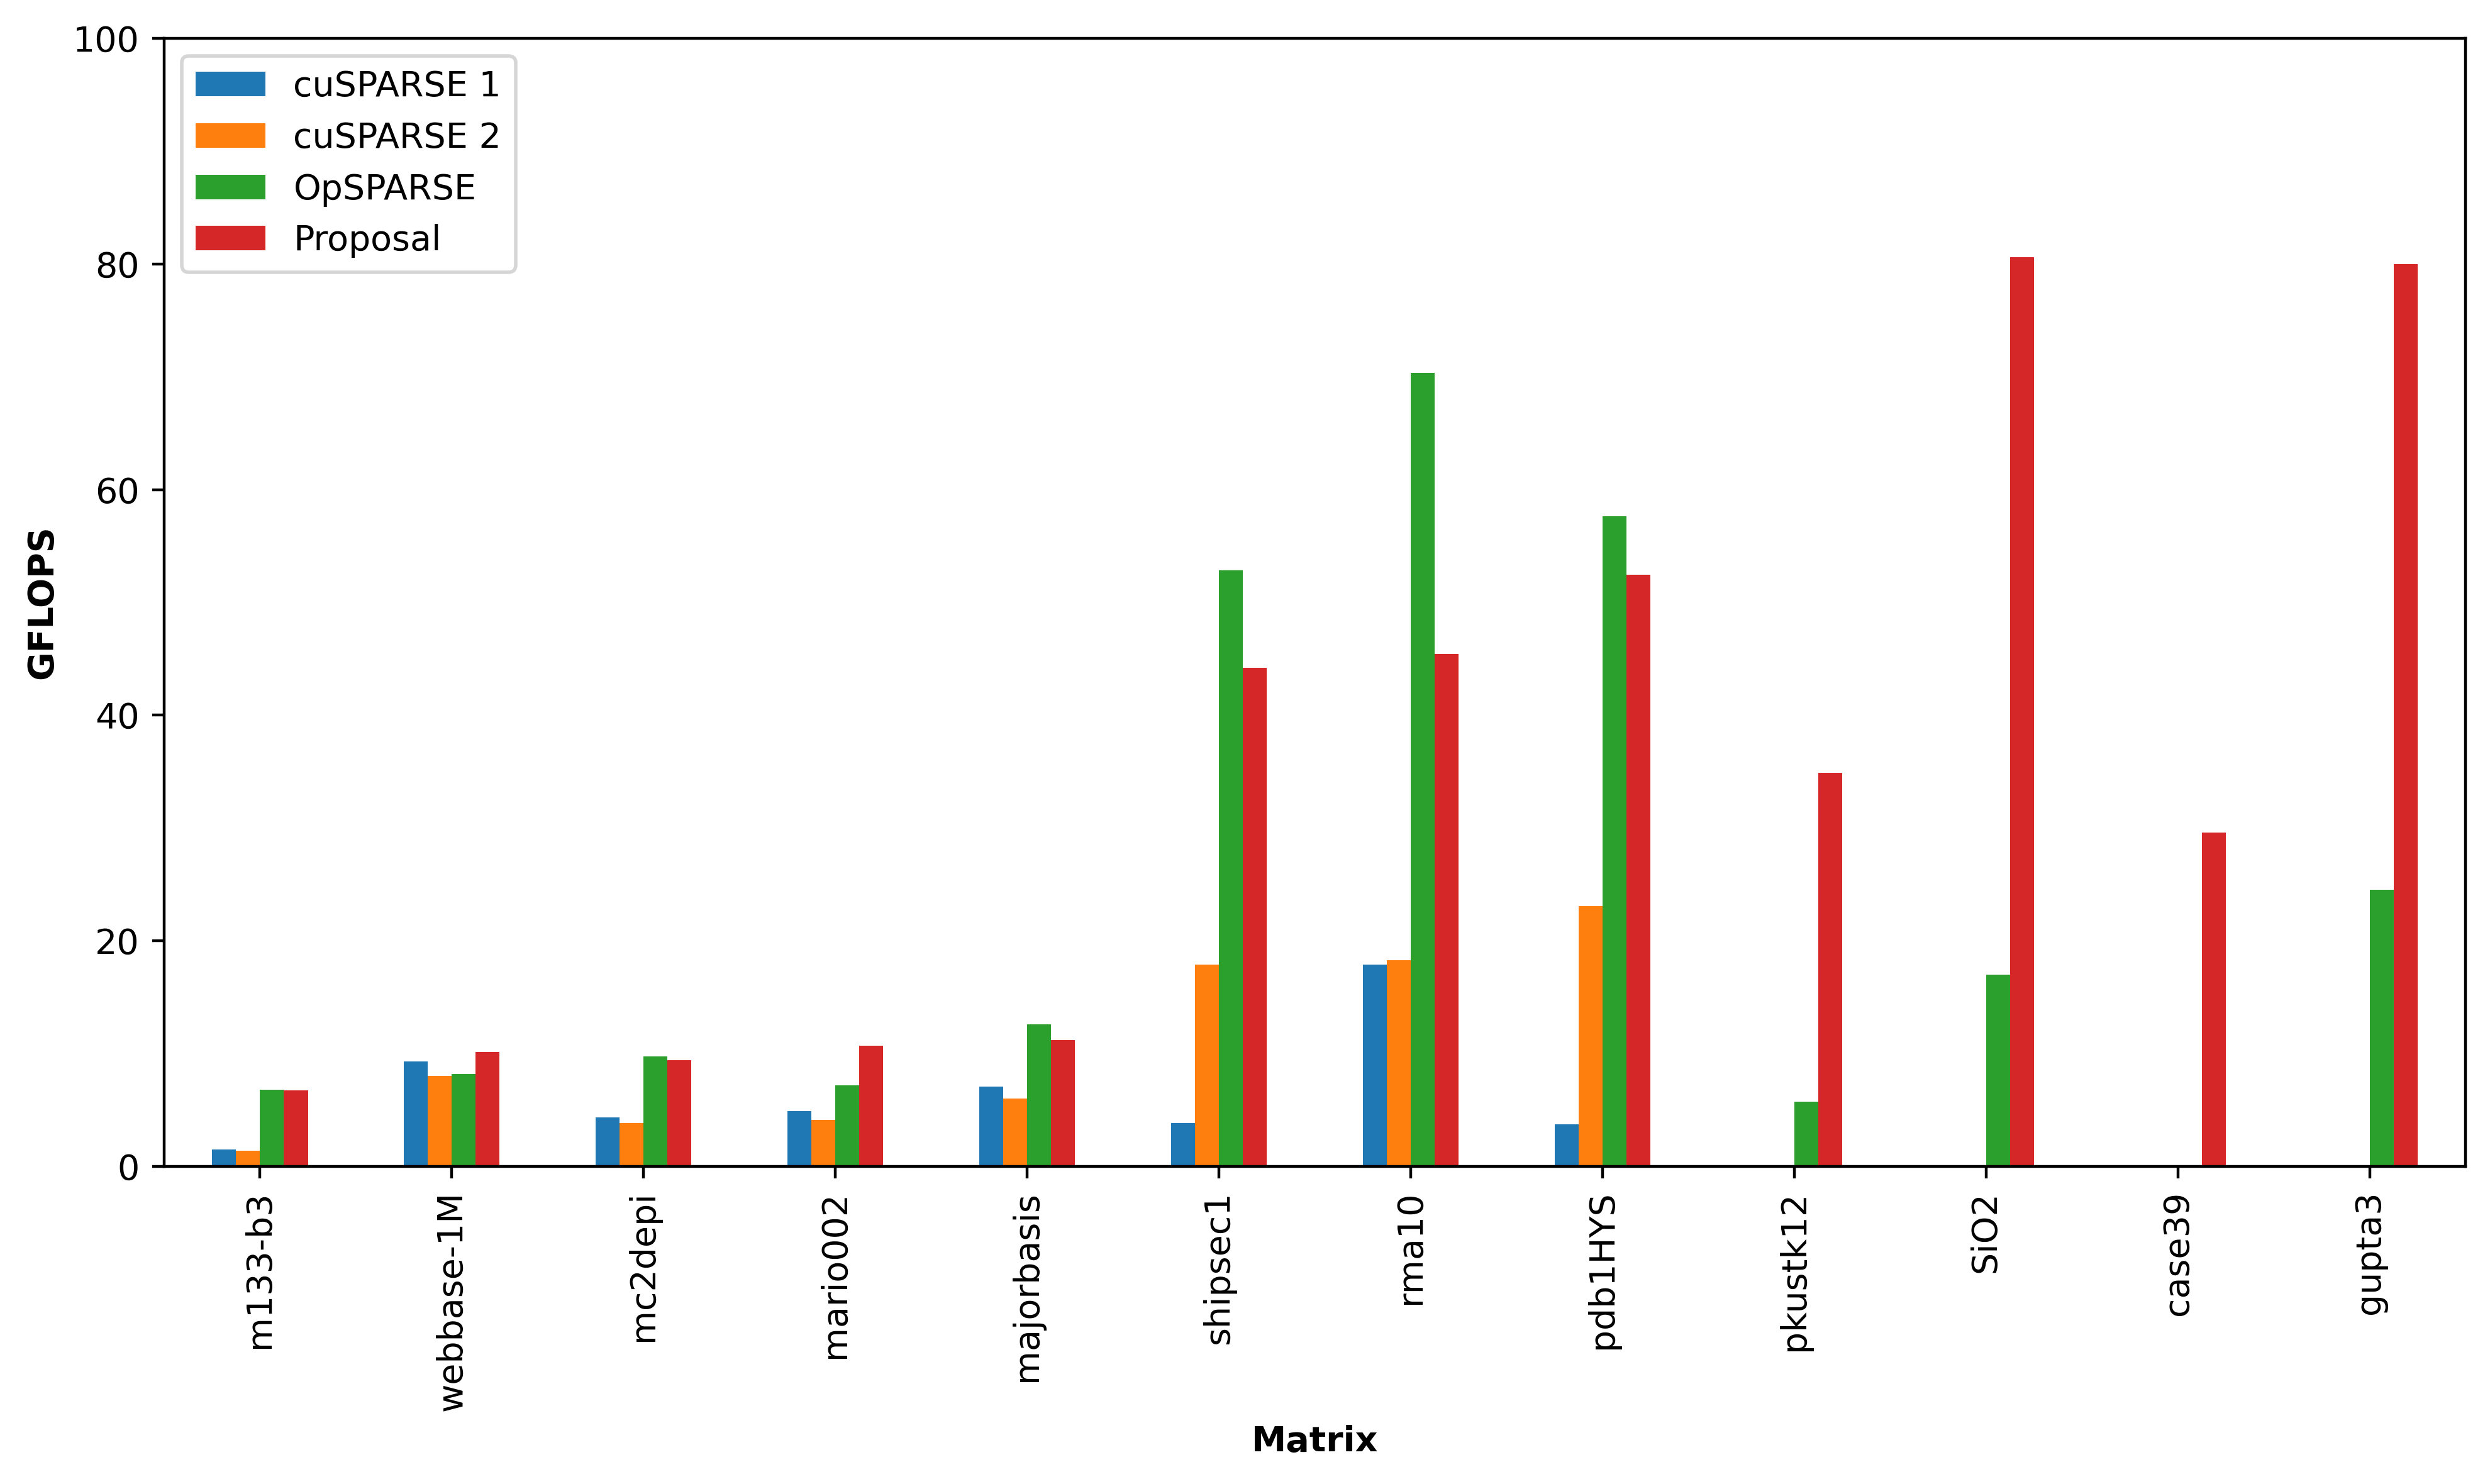

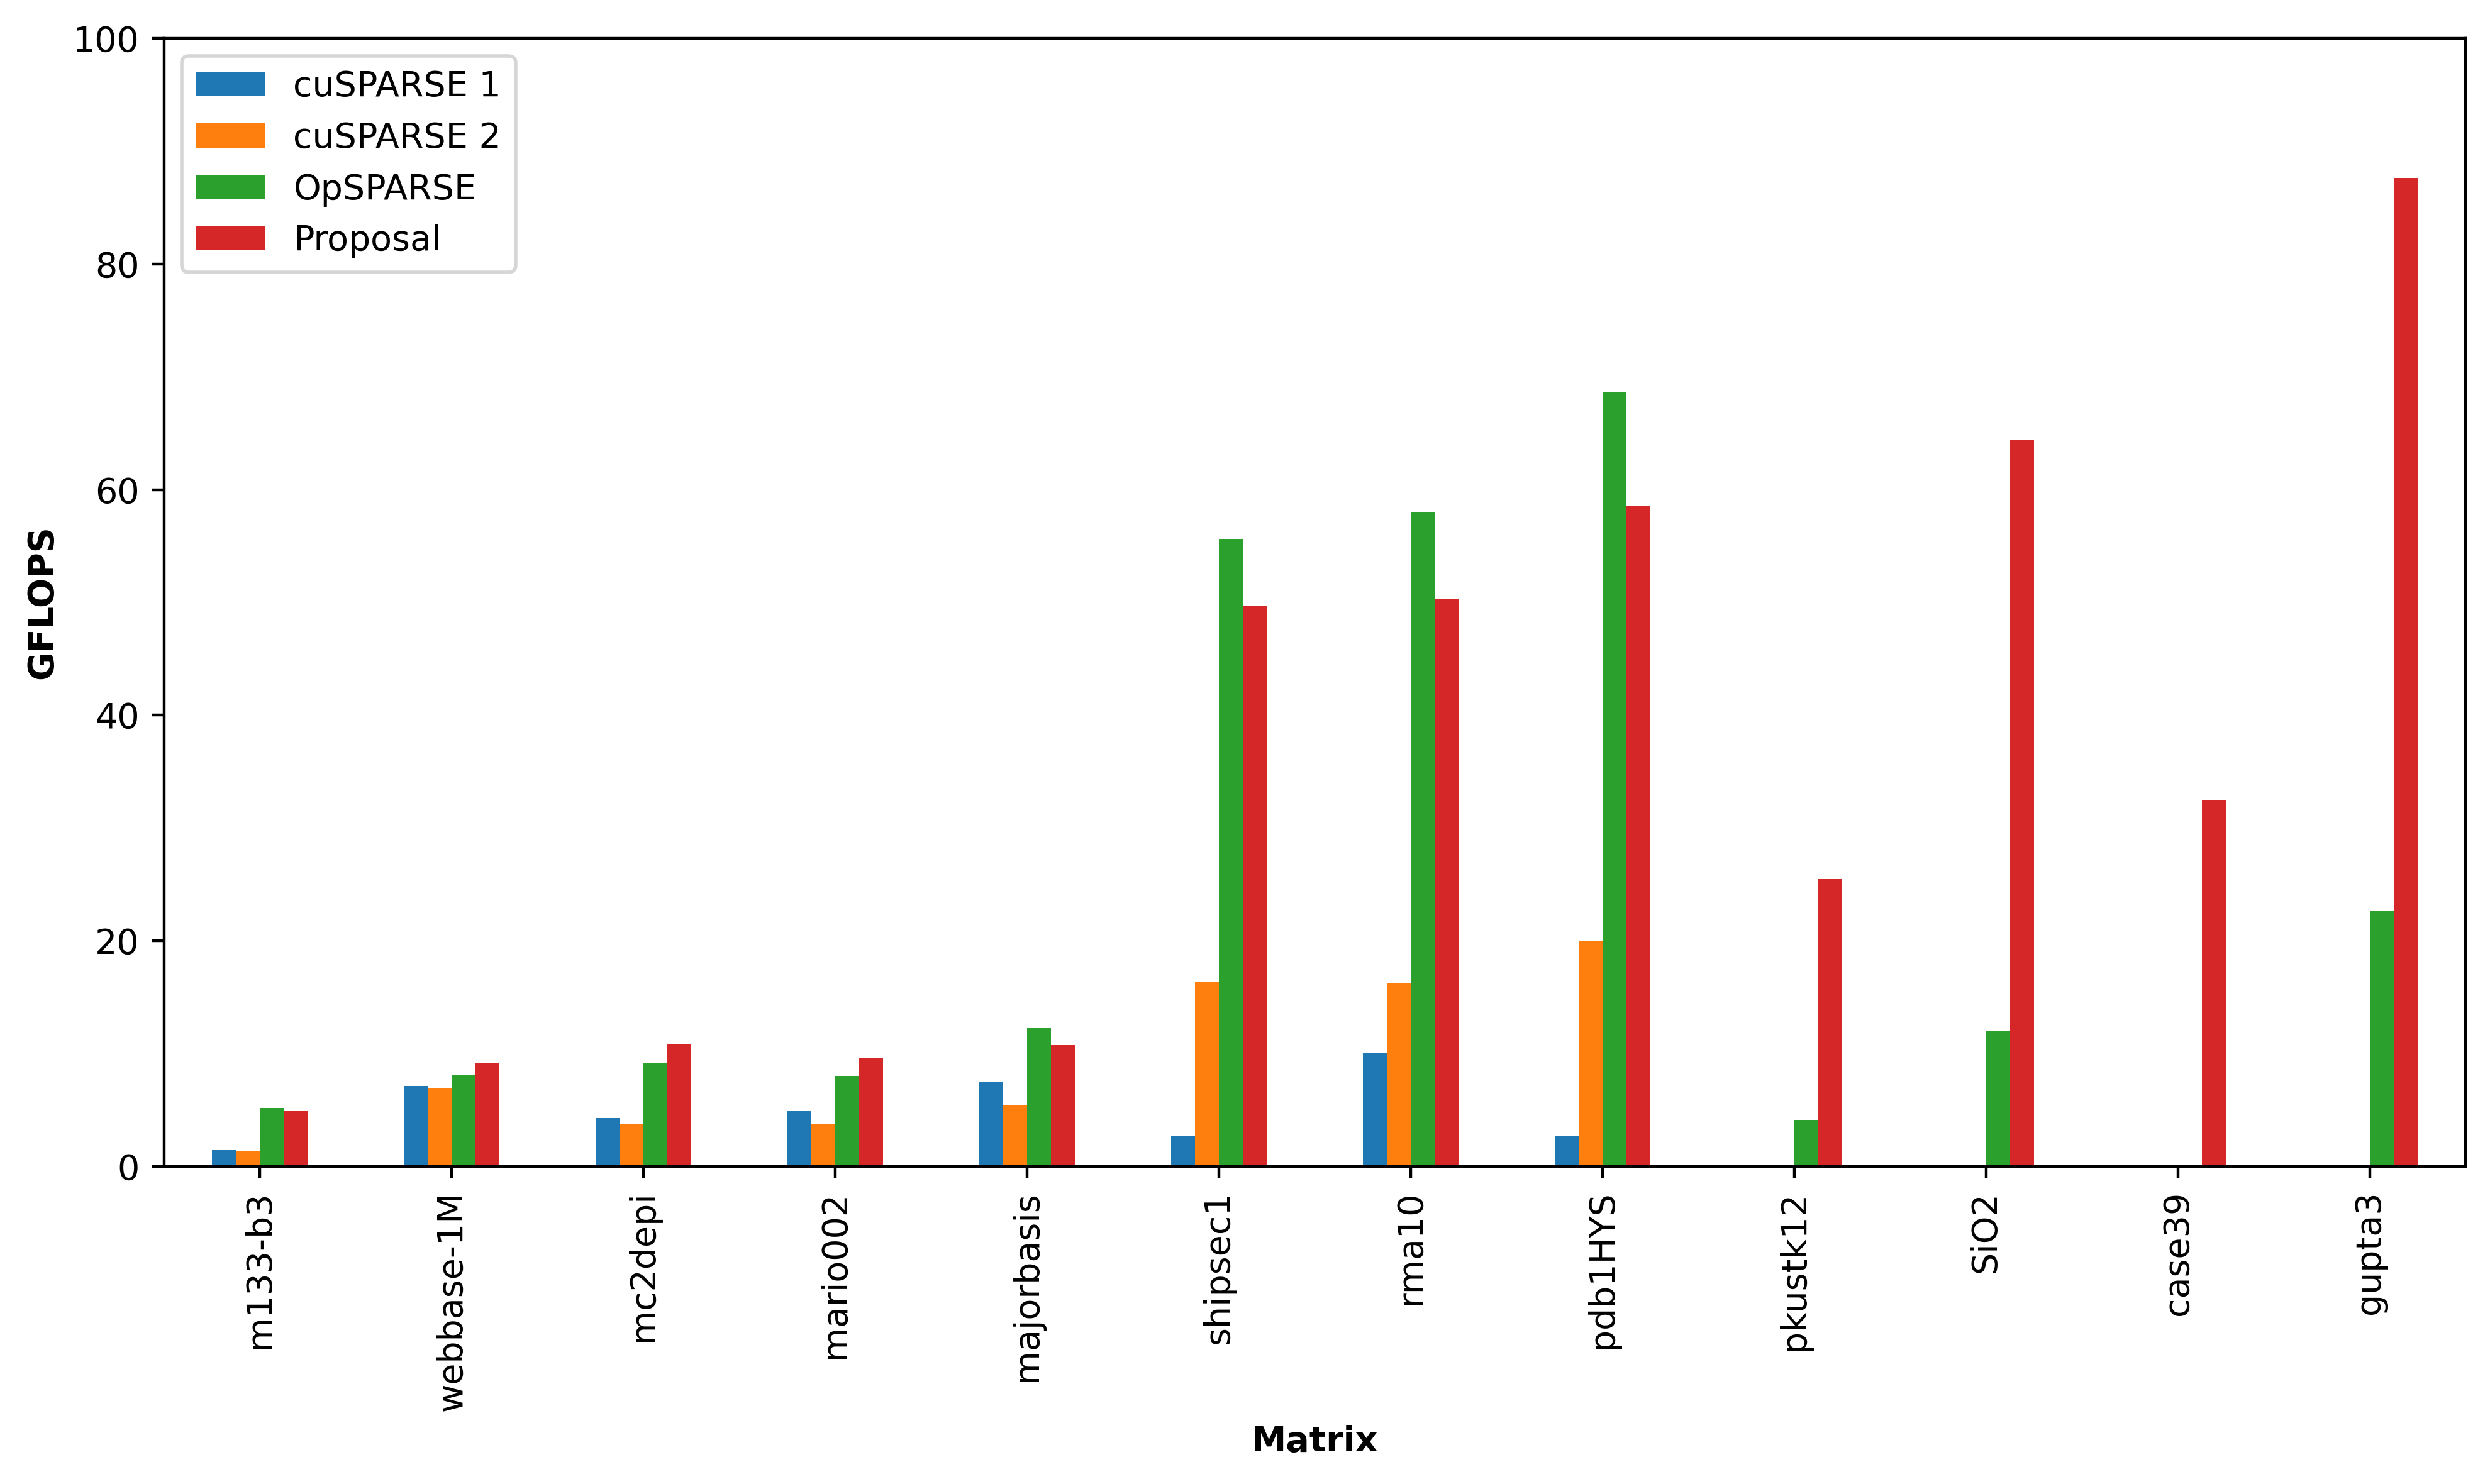

In [4]:
df_clusterfit_float = load_results("fitcluster", "float")
df_clusterfit_double = load_results("fitcluster", "double")

save_gflops_plot(df_clusterfit_float, FIGURES_DIR / "results-clusterfit-float.pdf")
save_gflops_plot(df_clusterfit_double, FIGURES_DIR / "results-clusterfit-double.pdf")

print("## Float best performing")
for algo in TARGETS:
    print(f"{algo}: {get_best_performing(df_clusterfit_float, algo)}")

print("## Double best performing")
for algo in TARGETS:
    print(f"{algo}: {get_best_performing(df_clusterfit_double, algo)}")

print("\n## Float speedups")
for algo in ["cusparse1", "cusparse2", "opsparse"]:
    speedup = df_clusterfit_float[f"{algo}-time"] / df_clusterfit_float["proposal-time"]
    speedup = speedup[speedup > 0]
    print(f"Proposal speedup over {algo}: {round(gmean(speedup), 2)}")

print("\n## Double speedups")
for algo in ["cusparse1", "cusparse2", "opsparse"]:
    speedup = (
        df_clusterfit_double[f"{algo}-time"] / df_clusterfit_double["proposal-time"]
    )
    speedup = speedup[speedup > 0]
    print(f"Proposal speedup over {algo}: {round(gmean(speedup), 2)}")

print("\n## Double is better than float")
print((df_clusterfit_double[GFLOPS_COLS] > df_clusterfit_float[GFLOPS_COLS]).sum())

In [5]:
df_clusterfit_float[GFLOPS_COLS]

,cusparse1-gflops,cusparse2-gflops,opsparse-gflops,proposal-gflops
matrix,,,,
m133-b3,1.486107,1.382346,6.804015,6.724720
webbase-1M,9.299329,8.012317,8.163977,10.141334
mc2depi,4.313455,3.841208,9.732756,9.418863
mario002,4.897994,4.108592,7.176043,10.711785
majorbasis,7.089510,6.018824,12.574513,11.198669
shipsec1,3.816971,17.902606,52.809498,44.186332
rma10,17.867163,18.251118,70.344838,45.408136
pdb1HYS,3.700236,23.077020,57.654381,52.432356
pkustk12,0.000000,0.000000,5.702587,34.884883


In [6]:
df_clusterfit_double[GFLOPS_COLS]

,cusparse1-gflops,cusparse2-gflops,opsparse-gflops,proposal-gflops
matrix,,,,
m133-b3,1.443647,1.375435,5.153768,4.893163
webbase-1M,7.147559,6.899085,8.081550,9.121813
mc2depi,4.252808,3.805562,9.158259,10.848519
mario002,4.871032,3.776840,8.034393,9.549369
majorbasis,7.432831,5.394038,12.238527,10.723087
shipsec1,2.716516,16.336155,55.611397,49.731206
rma10,10.053624,16.258375,58.014879,50.284723
pdb1HYS,2.669016,19.983662,68.663277,58.517654
pkustk12,0.000000,0.000000,4.118553,25.453173


## Cluster Star

## Float best performing
cusparse1: 0
cusparse2: 0
opsparse: 4
proposal: 8
## Double best performing
cusparse1: 0
cusparse2: 0
opsparse: 2
proposal: 10

## Float speedups
Proposal speedup over cusparse1: 4.25
Proposal speedup over cusparse2: 3.37
Proposal speedup over opsparse: 1.35

## Double speedups
Proposal speedup over cusparse1: 3.45
Proposal speedup over cusparse2: 3.18
Proposal speedup over opsparse: 1.36

## Double is better than float
cusparse1-gflops    0
cusparse2-gflops    1
opsparse-gflops     0
proposal-gflops     0
dtype: int64


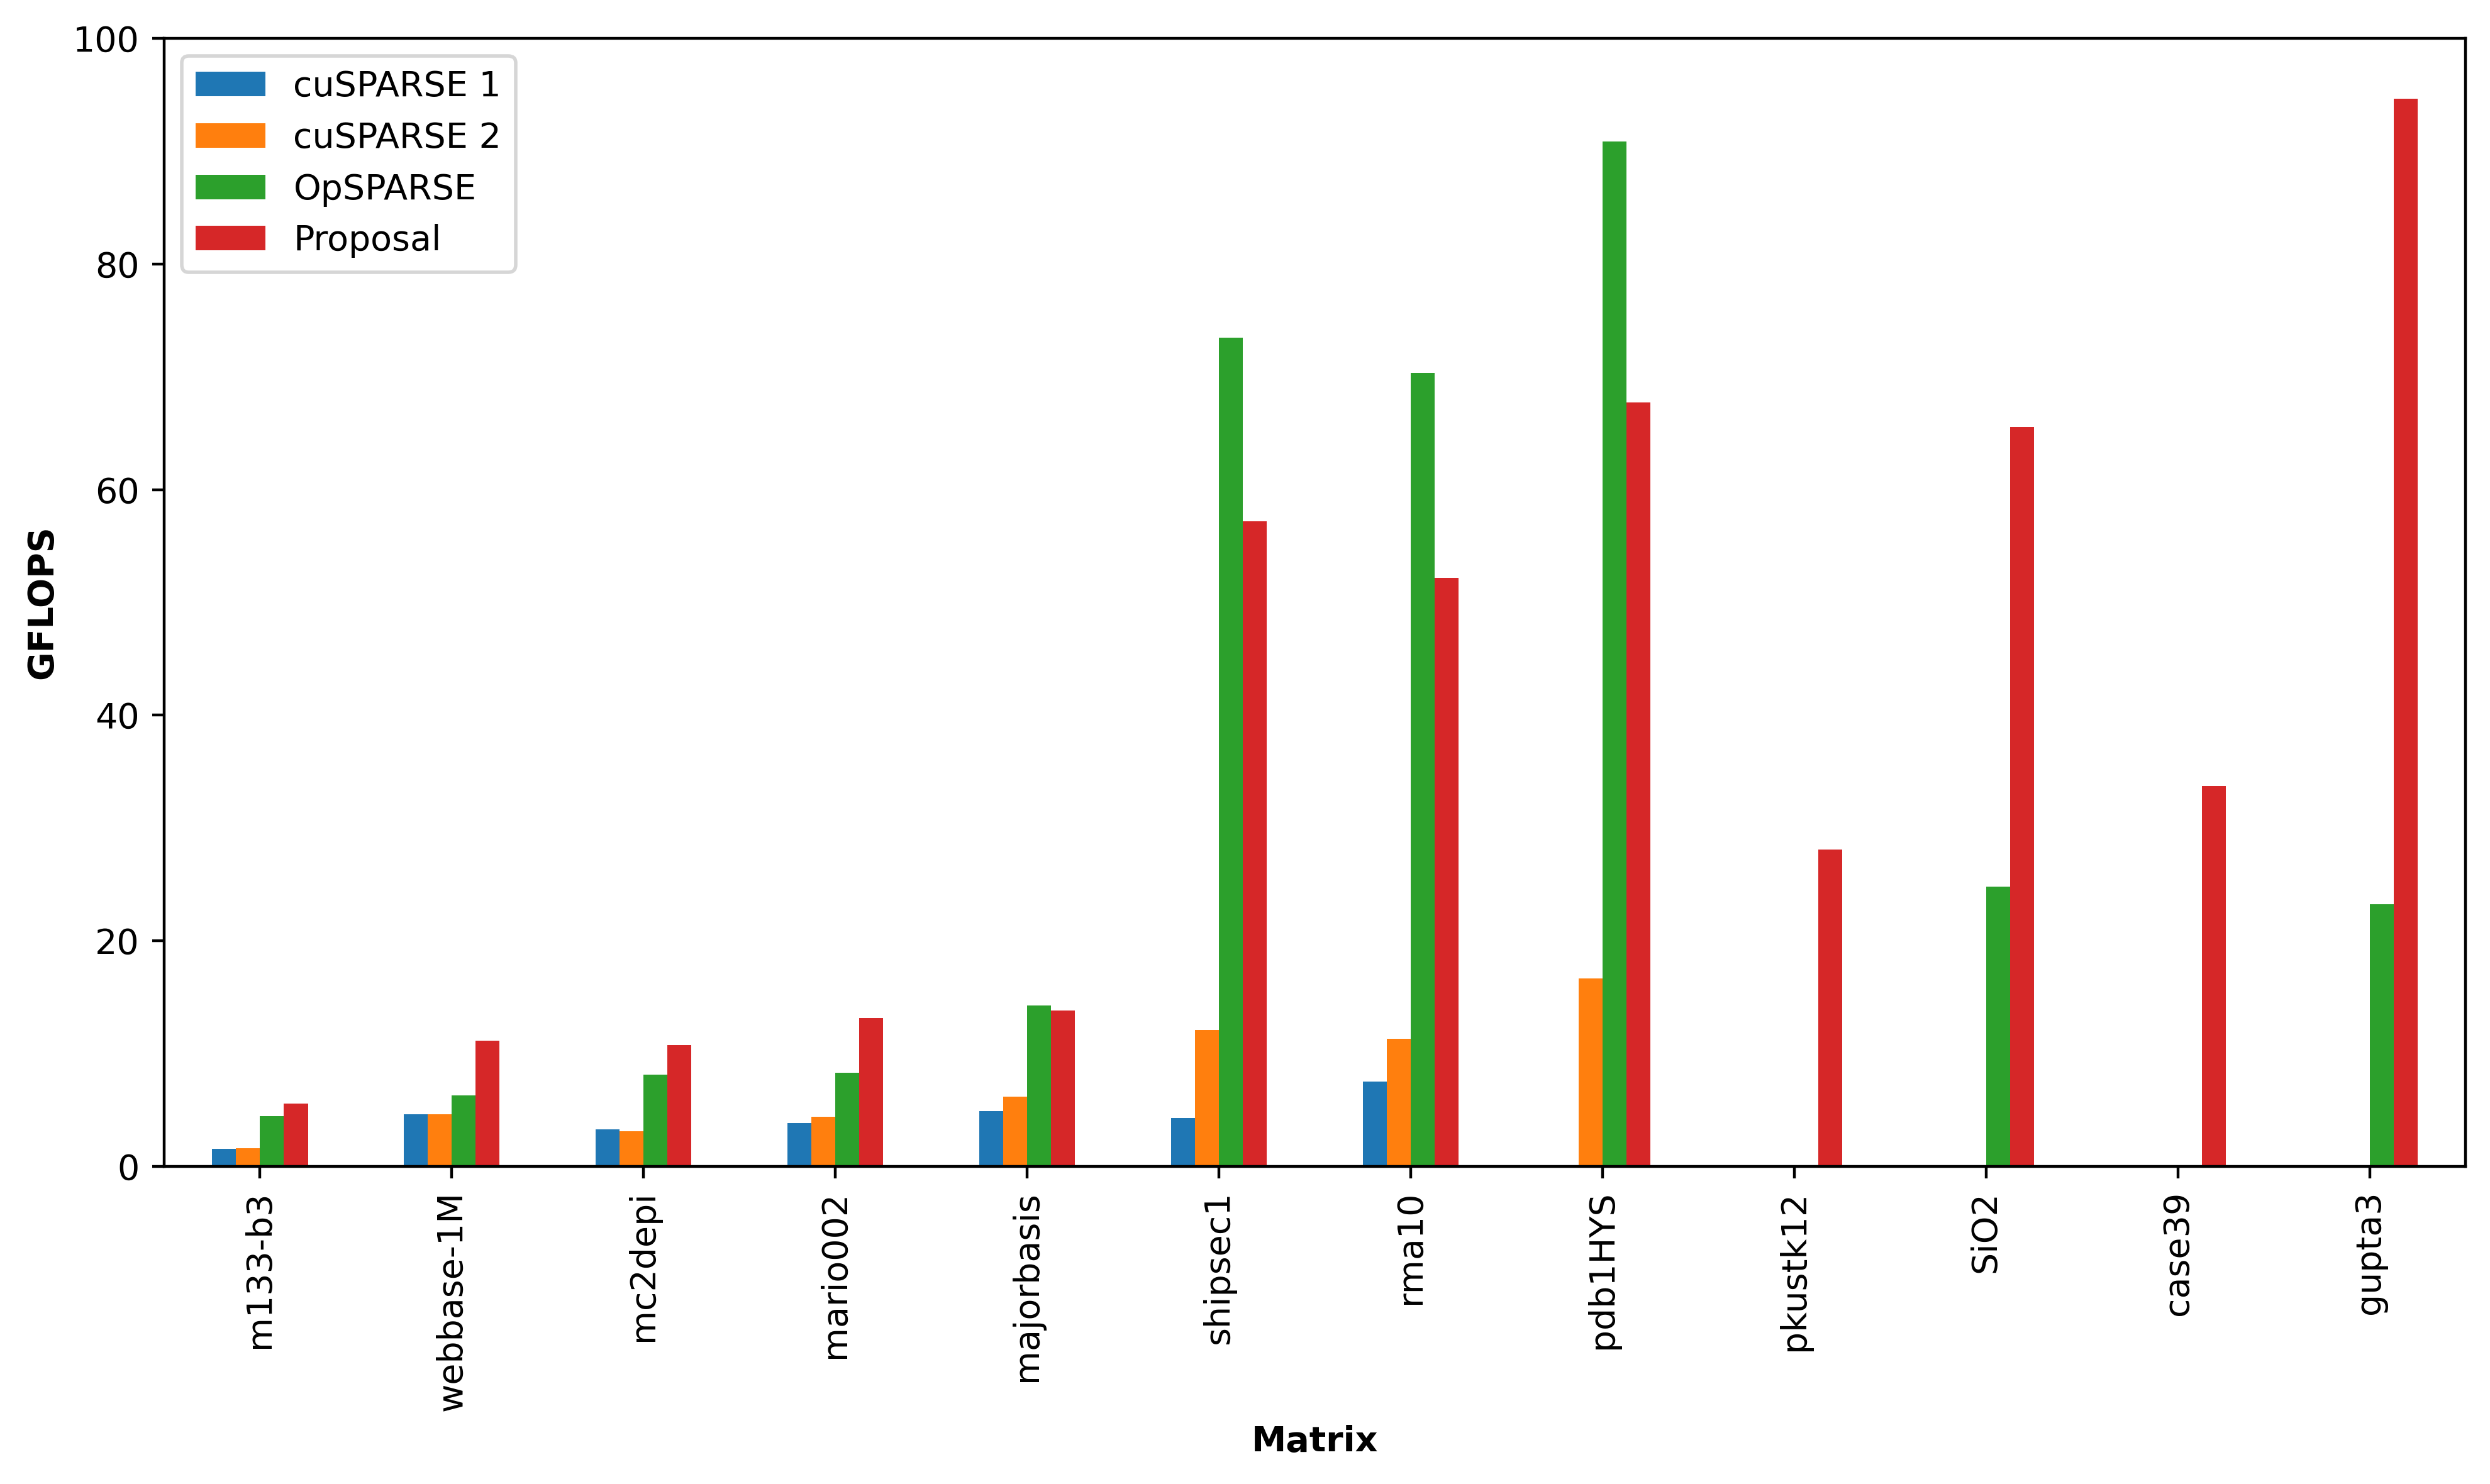

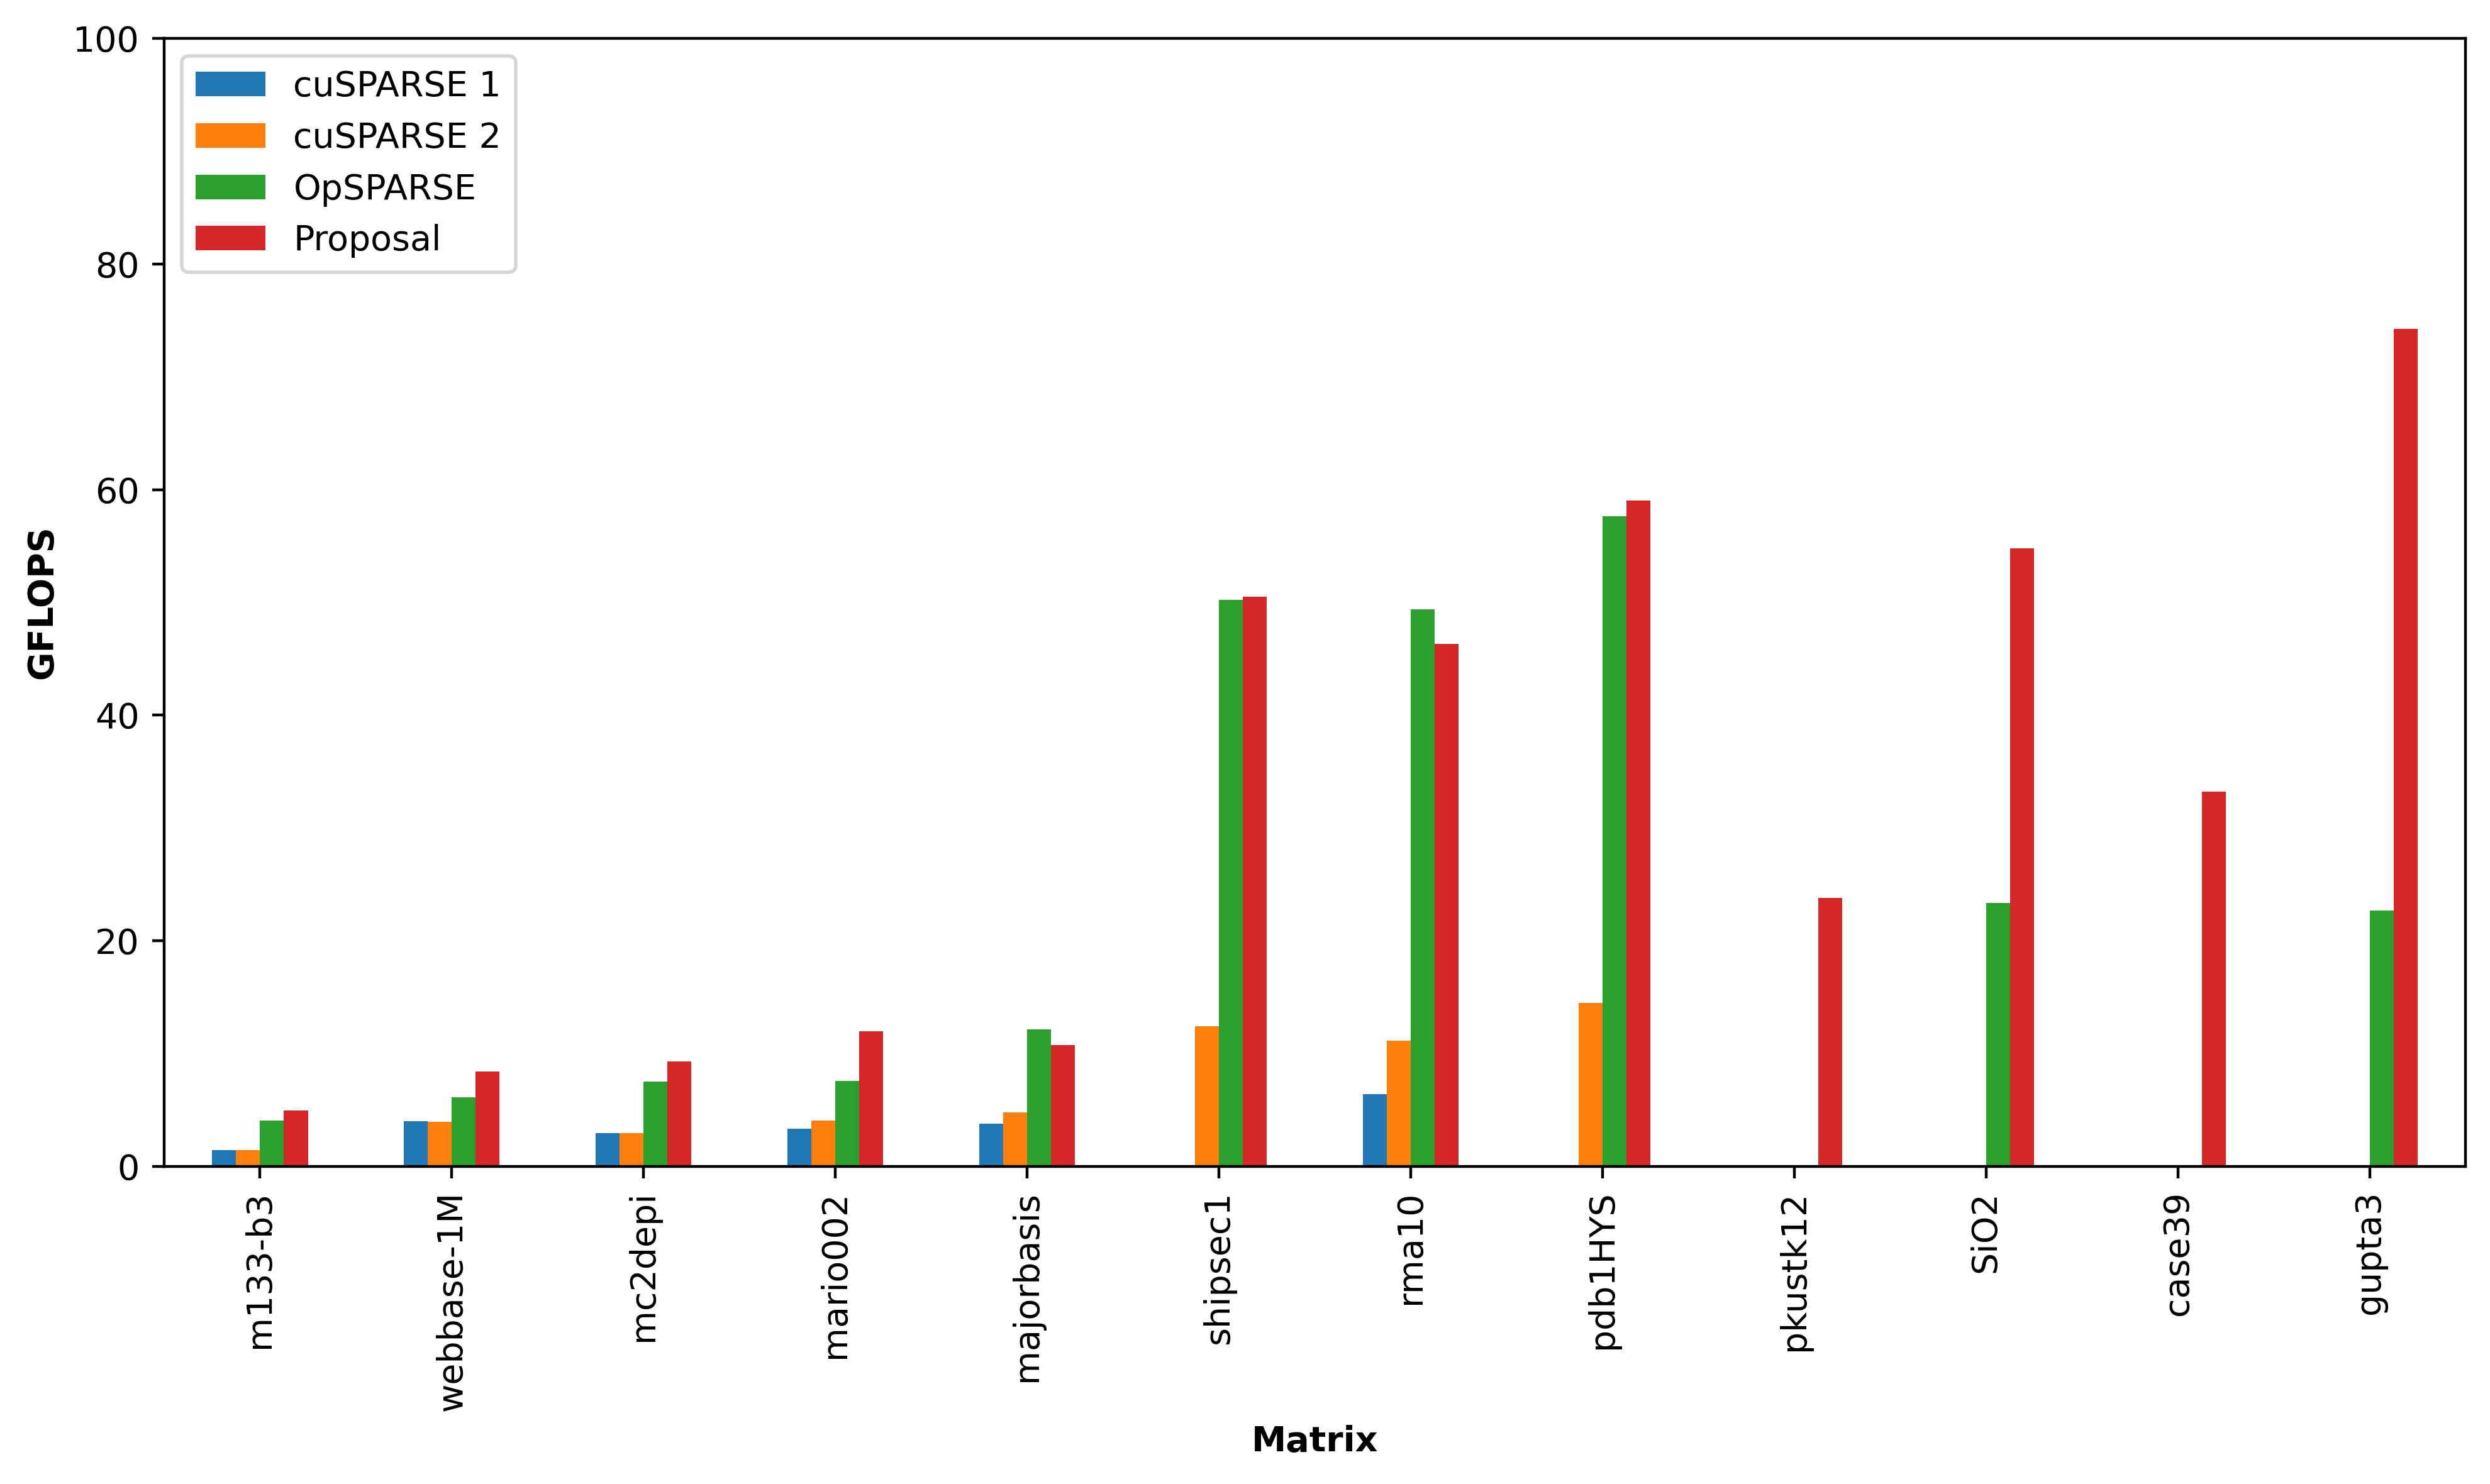

In [7]:
df_clusterstar_float = load_results("fitstar", "float")
df_clusterstar_double = load_results("fitstar", "double")

save_gflops_plot(df_clusterstar_float, FIGURES_DIR / "results-clusterstar-float.pdf")
save_gflops_plot(df_clusterstar_double, FIGURES_DIR / "results-clusterstar-double.pdf")

print("## Float best performing")
for algo in TARGETS:
    print(f"{algo}: {get_best_performing(df_clusterstar_float, algo)}")

print("## Double best performing")
for algo in TARGETS:
    print(f"{algo}: {get_best_performing(df_clusterstar_double, algo)}")

print("\n## Float speedups")
for algo in ["cusparse1", "cusparse2", "opsparse"]:
    speedup = (
        df_clusterstar_float[f"{algo}-time"] / df_clusterstar_float["proposal-time"]
    )
    speedup = speedup[speedup > 0]
    print(f"Proposal speedup over {algo}: {round(gmean(speedup), 2)}")

print("\n## Double speedups")
for algo in ["cusparse1", "cusparse2", "opsparse"]:
    speedup = (
        df_clusterstar_double[f"{algo}-time"] / df_clusterstar_double["proposal-time"]
    )
    speedup = speedup[speedup > 0]
    print(f"Proposal speedup over {algo}: {round(gmean(speedup), 2)}")

print("\n## Double is better than float")
print((df_clusterstar_double[GFLOPS_COLS] > df_clusterstar_float[GFLOPS_COLS]).sum())

In [8]:
df_clusterstar_float[GFLOPS_COLS]

,cusparse1-gflops,cusparse2-gflops,opsparse-gflops,proposal-gflops
matrix,,,,
m133-b3,1.565828,1.627545,4.433275,5.540384
webbase-1M,4.594763,4.600902,6.290436,11.125978
mc2depi,3.281695,3.130082,8.107236,10.748464
mario002,3.858641,4.394433,8.282712,13.138480
majorbasis,4.897706,6.179822,14.268494,13.788624
shipsec1,4.255754,12.076355,73.442851,57.204024
rma10,7.514983,11.311440,70.323167,52.189964
pdb1HYS,0.000000,16.683345,90.849782,67.738878
pkustk12,0.000000,0.000000,0.000000,28.096745


In [9]:
df_clusterstar_double[GFLOPS_COLS]

,cusparse1-gflops,cusparse2-gflops,opsparse-gflops,proposal-gflops
matrix,,,,
m133-b3,1.427781,1.439910,4.047905,4.931552
webbase-1M,4.020213,3.970524,6.146595,8.427300
mc2depi,2.939058,2.961927,7.489159,9.309059
mario002,3.355950,4.037668,7.541623,11.949732
majorbasis,3.772753,4.803270,12.126048,10.762367
shipsec1,0.000000,12.429862,50.201523,50.467360
rma10,6.422923,11.124001,49.357678,46.331907
pdb1HYS,0.000000,14.464993,57.646950,59.022994
pkustk12,0.000000,0.000000,0.000000,23.812981


## Both

In [10]:
df_clusterfit_double[GFLOPS_COLS] / df_clusterstar_double[GFLOPS_COLS]

,cusparse1-gflops,cusparse2-gflops,opsparse-gflops,proposal-gflops
matrix,,,,
m133-b3,1.011113,0.955223,1.273194,0.992216
webbase-1M,1.777905,1.737575,1.314801,1.082412
mc2depi,1.446997,1.284826,1.222869,1.165372
mario002,1.451461,0.935401,1.065340,0.799128
majorbasis,1.970135,1.122993,1.009276,0.996350
shipsec1,inf,1.314267,1.107763,0.985413
rma10,1.565272,1.461558,1.175397,1.085315
pdb1HYS,inf,1.381519,1.191100,0.991438
pkustk12,NaN,NaN,inf,1.068878


In [11]:
df_clusterfit_float[GFLOPS_COLS] / df_clusterstar_float[GFLOPS_COLS]

,cusparse1-gflops,cusparse2-gflops,opsparse-gflops,proposal-gflops
matrix,,,,
m133-b3,0.949087,0.849344,1.534760,1.213764
webbase-1M,2.023897,1.741467,1.297839,0.911500
mc2depi,1.314399,1.227191,1.200502,0.876298
mario002,1.269357,0.934954,0.866388,0.815299
majorbasis,1.447516,0.973948,0.881278,0.812167
shipsec1,0.896896,1.482451,0.719056,0.772434
rma10,2.377539,1.613510,1.000308,0.870055
pdb1HYS,inf,1.383237,0.634612,0.774036
pkustk12,NaN,NaN,inf,1.241599
